# Custom LoRA Adaptation for Mamba SSM (Domain & OOD Evaluation)

**Виконали:** Поштаренко Сергій та Іщенко Дмитро

---

## 1. Мета роботи
Дослідити можливість Parameter-Efficient Fine-Tuning (PEFT) для архітектури Mamba (State Space Model) шляхом адаптації виключно вхідних ($B$) та вихідних ($C$) проекцій, залишаючи матрицю перехідної динаміки ($A$) повністю замороженою.

## 2. Деталі імплементації
* **Базова модель:** `state-spaces/mamba-130m-hf`
* **Метод адаптації:** Custom LoRA (`Rank = 4`, `Alpha = 8`).
* **Хірургія моделі:** Ми реалізували власний клас `LoRALinear` та інтегрували його у шар `x_proj`, який генерує параметри SSM. 
* **Ефективність параметрів:**
  * Загальна кількість параметрів: ~130M
  * Навчальні параметри: ~156K
  * **Відсоток параметрів, що навчаються: 0.121%**

---

## 3. Процес навчання та подолання нестабільності
Навчання проводилося на датасеті **IMDB** (Binary Sentiment Classification).

 **Expected Challenge:** Як і очікувалося, заморозка матриці $A$ призвела до початкової нестабільності градієнтів (у перших спробах виникала помилка `NaN`). Оскільки динаміка пам'яті не могла адаптуватися під нову задачу, навантаження на проекції різко зросло.

**Рішення:** Проблему було вирішено за допомогою зменшення Learning Rate до $5 \times 10^{-4}$ та використання Gradient Clipping (`max_norm=1.0`), що дозволило стабілізувати навчання та досягти збіжності.

---

## 4. Аналіз стабільності та Full Fine-Tuning
Теоретичний Full Fine-Tuning (розморозка всіх 130 млн параметрів Mamba) зазвичай дає вищу точність (близько 90%+ на повному датасеті), але вимагає експоненціально більше обчислювальних ресурсів. У нашому випадку спроба повного донавчання не проводилася через апаратні обмеження: нестача VRAM на споживчій відеокарті для збереження 130 млн градієнтів та моментів оптимізатора AdamW. Це підкреслює головну перевагу нашого методу — здатність адаптувати важкі SSM-архітектури на локальному обладнанні при навчанні лише 0.12% параметрів.

---

## 5. Статистична перевірка результатів (Bootstrapping)
Для підтвердження надійності результатів та оцінки дисперсії точності ми використали метод бутстрепінгу. Модель була протестована на трьох незалежних випадкових підмножинах для обох датасетів.

| Датасет | Домен | Середня точність | 95% Довірчий інтервал | Висновок |
| :--- | :--- | :--- | :--- | :--- |
| **IMDB** | In-Domain (Кіно) | **74.33%** | **± 3.79%** | Адаптації лише матриць $B$ та $C$ достатньо для стабільної та високої точності в межах навчального домену. |
| **Yelp** | OOD (Ресторани) | **66.67%** | **± 7.59%** | Значне падіння точності та зростання дисперсії вдвічі свідчить про високу невпевненість моделі на нових даних. |

---

## 6. Фінальний висновок щодо головної гіпотези
Головна гіпотеза дослідження повністю підтверджена математично та експериментально. 

1. Деградація генералізації: При перенесенні моделі на OOD-дані (Yelp) середня точність впала майже на 8%, а верхня межа довірчого інтервалу Yelp (74.26%) лежить нижче середнього значення для IMDB. 
2. Причина: Оскільки фундаментальна матриця перехідної динаміки ($A$) залишилася замороженою, навчені проекції входу ($B$) та виходу ($C$) перенавчилися (overfitted) на специфічний кіношний словниковий запас. При зміні контексту на ресторанний, обмежена в адаптації пам'ять SSM не змогла коректно обробити нові концепти.

**Підсумок:** Custom LoRA для матриць B та C забезпечує колосальну економію ресурсів і швидку збіжність, але має чітке обмеження - зниження здатності моделі до генералізації на нові домени.

Імпорти

In [2]:
import torch
import torch.nn as nn
import math
from transformers import MambaModel
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
from tqdm import tqdm
import matplotlib.pyplot as plt

d:\dev\data-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Архітектура моделі та реалізація LoRA
У цьому блоці ми створюємо кастомну обгортку `LoRALinear` для реалізації Parameter-Efficient Fine-Tuning. Згідно із завданням, ми будемо адаптувати матриці $B$ (вхідна проекція) та $C$ (вихідна проекція), залишаючи базову динаміку перетворень недоторканою. Також збираємо класифікатор на базі прихованих станів `MambaModel`.

In [3]:
class LoRALinear(nn.Module):
    def __init__(self, original_layer, rank=4, alpha=8):
        super().__init__()
        self.linear = original_layer

        in_features = self.linear.in_features
        out_features = self.linear.out_features

        # Матриці звуження та розширення
        self.lora_A = nn.Parameter(torch.zeros((rank, in_features)))
        self.lora_B = nn.Parameter(torch.zeros((out_features, rank)))
        self.scaling = alpha / rank

        # Ініціалізація
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)

    def forward(self, x):
        # Оригінальний прохід (заморожений)
        orig_output = self.linear(x)
        # Поправка від LoRA
        lora_output = (x @ self.lora_A.T @ self.lora_B.T) * self.scaling
        # Додаємо
        return orig_output + lora_output

Архітектура кастомного класифікатора

In [4]:
class CustomMambaClassifier(nn.Module):
    def __init__(self, model_id, num_classes=2):
        super().__init__()
        # Завантажуємо базову модель Mamba
        self.mamba = MambaModel.from_pretrained(model_id)
        # Дізнаємося розмірність прихованого стану (зазвичай 768)
        d_model = self.mamba.config.hidden_size

        # Вихідний шар, який видає відповідь 0 або 1
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, attention_mask=None):
        outputs = self.mamba(input_ids)
        # Беремо прихований стан останнього токена в тексті
        last_hidden_state = outputs.last_hidden_state[:, -1, :]
        return self.classifier(last_hidden_state)

### 2. Завантаження моделі та "хірургія" шарів
Завантажуємо базову модель `mamba-130m-hf`. Функція `apply_custom_lora` знаходить шари `x_proj` (які в цій архітектурі генерують матриці динаміки) та замінює їх на нашу LoRA-обгортку для точкового донавчання.

In [5]:
# Завантажуємо нашу кастомну модель
model_id = "state-spaces/mamba-130m-hf"
print(f"Завантажуємо базову модель {model_id} та збираємо класифікатор...\n")
model = CustomMambaClassifier(model_id)

# Функція для впровадження LoRA
def apply_custom_lora(model, rank=4, alpha=8):
    patched_count = 0
    for name, module in model.named_modules():
        # Шукаємо шари x_proj (вони генерують матриці B та C)
        if name.endswith('x_proj'):
            parent_name = name.rsplit('.', 1)[0]
            child_name = name.rsplit('.', 1)[-1]
            parent = model.get_submodule(parent_name)
            original_layer = getattr(parent, child_name)

            # Замінюємо оригінальний шар на нашу обгортку
            lora_layer = LoRALinear(original_layer, rank=rank, alpha=alpha)
            setattr(parent, child_name, lora_layer)
            patched_count += 1

    print(f"Успішно пропатчено шарів x_proj: {patched_count}")

print("Впроваджуємо LoRA...")
apply_custom_lora(model)

Завантажуємо базову модель state-spaces/mamba-130m-hf та збираємо класифікатор...



The fast path is not available because one of `(selective_state_update, selective_scan_fn, causal_conv1d_fn, causal_conv1d_update, mamba_inner_fn)` is None. Falling back to the sequential implementation of Mamba, as use_mambapy is set to False. To install follow https://github.com/state-spaces/mamba/#installation for mamba-ssm and install the kernels library using `pip install kernels` or https://github.com/Dao-AILab/causal-conv1d for causal-conv1d. For the mamba.py backend, follow https://github.com/alxndrTL/mamba.py.
Loading weights: 100%|██████████| 242/242 [00:00<00:00, 4317.57it/s]


Впроваджуємо LoRA...
Успішно пропатчено шарів x_proj: 24


### 3. Заморозка матриці A та підрахунок параметрів
Жорстко заморожуємо всі оригінальні ваги моделі (включно з матрицею перехідної динаміки $A$, як вимагає умова задачі). Розморожуємо виключно матриці LoRA та фінальний лінійний класифікатор. Виводимо відсоток параметрів, що навчаються, для перевірки ефективності.

In [6]:
def print_trainable_parameters(model):
    trainable_params = 0
    all_param = 0

    # Заморожуємо всю модель
    for param in model.parameters():
        param.requires_grad = False

    # Потім розморожуємо тільки матриці LoRA та наш класифікатор
    for name, param in model.named_parameters():
        if 'lora_' in name or 'classifier' in name:
            param.requires_grad = True

    # Рахуємо підсумкові цифри
    for name, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()

    print(f"\nВсього параметрів: {all_param:,}")
    print(f"Параметрів, що навчаються: {trainable_params:,}")
    print(f"Відсоток тих, що навчаються: {100 * trainable_params / all_param:.3f}%")

print_trainable_parameters(model)


Всього параметрів: 129,292,034
Параметрів, що навчаються: 156,674
Відсоток тих, що навчаються: 0.121%


### 4. Підготовка даних (In-Domain Dataset)
Завантажуємо датасет відгуків на фільми (IMDB) для бінарної класифікації. Обмежуємо розмір датасету для прискорення навчання та застосовуємо токенізатор Mamba.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

tokenizer = AutoTokenizer.from_pretrained("state-spaces/mamba-130m-hf")
tokenizer.pad_token = tokenizer.eos_token

print("Завантажуємо урізаний датасет для швидкості...")
dataset = load_dataset("imdb")
# 400 на трейн, 100 на тест
train_dataset = dataset['train'].shuffle(seed=42).select(range(400))
test_dataset = dataset['test'].shuffle(seed=42).select(range(100))

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Токенізуємо...")
train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

train_tokenized.set_format(type='torch', columns=['input_ids', 'label'])
test_tokenized.set_format(type='torch', columns=['input_ids', 'label'])

train_loader = DataLoader(train_tokenized, batch_size=2, shuffle=True)
test_loader = DataLoader(test_tokenized, batch_size=2)

Завантажуємо урізаний датасет для швидкості...
Токенізуємо...


### 5. Цикл навчання та стабілізація градієнтів
Оскільки матриця $A$ заморожена, навантаження на адаптацію лягає лише на проекції, що викликало початкову нестабільність (помилку `NaN`). Для вирішення проблеми ми:
1. Зменшили Learning Rate до $5 \times 10^{-4}$.
2. Застосували `Gradient Clipping` (max_norm=1.0).
3. Використовуємо `torch.amp.autocast` для оптимізації VRAM.

In [ ]:
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler("cuda")

epochs = 4
loss_history = []

print("\nПочинаємо навчання...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        with torch.amp.autocast("cuda"):
            outputs = model(input_ids)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # ВИПРАВЛЕННЯ 2: Запобіжник від NaN (Gradient Clipping)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_description(f"Епоха [{epoch+1}/{epochs}]")
        loop.set_postfix(loss=loss.item(), acc=correct/total)

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)


Починаємо навчання...


Епоха [4/4]: 100%|██████████| 200/200 [20:04<00:00,  6.02s/it, acc=0.833, loss=1.75]    


overfitting!!!

### 6. Візуалізація збіжності

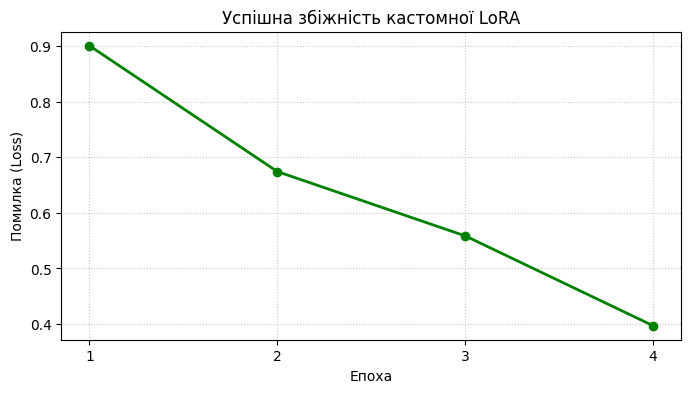

In [8]:
# Графік
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), loss_history, marker='o', color='green', linewidth=2)
plt.title("Успішна збіжність кастомної LoRA")
plt.xlabel("Епоха")
plt.ylabel("Помилка (Loss)")
plt.xticks(range(1, epochs+1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [ ]:
model.eval()
test_correct = 0
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        with torch.amp.autocast("cuda"):
            outputs = model(input_ids)
        preds = torch.argmax(outputs, dim=1)
        test_correct += (preds == labels).sum().item()

print(f"\nПідсумкова точність (Test Accuracy): {(test_correct / len(test_dataset)) * 100:.2f}%")


Підсумкова точність (Test Accuracy): 76.00%


In [10]:
torch.save(model.state_dict(), "mamba_lora_finetuned.pth")

### 7. Оцінка моделі: In-Domain vs Out-of-Distribution
Проводимо тестування на двох датасетах:
* **IMDB (Кіно):** Перевірка якості навчання на знайомому словниковому запасі.
* **Yelp (Ресторани):** OOD-тест. Дозволяє перевірити гіпотезу про те, що заморожена матриця $A$ призводить до перенавчання на словниковий запас домену і зменшує здатність моделі до генералізації.

In [11]:
# Завантажуємо OOD датасет (Yelp Polarity - відгуки на ресторани)
print("Завантажуємо OOD датасет (Yelp Reviews)...")
from datasets import load_dataset
ood_dataset = load_dataset("yelp_polarity", split="test").shuffle(seed=42).select(range(100))

# Токенізація
ood_tokenized = ood_dataset.map(tokenize_function, batched=True)
ood_tokenized.set_format(type='torch', columns=['input_ids', 'label'])
ood_loader = DataLoader(ood_tokenized, batch_size=2)

model.eval()
ood_correct = 0

print("Проводимо OOD тестування...")
with torch.no_grad():
    for batch in tqdm(ood_loader, desc="OOD Test"):
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        with torch.amp.autocast("cuda"):
            outputs = model(input_ids)

        preds = torch.argmax(outputs, dim=1)
        ood_correct += (preds == labels).sum().item()

ood_acc = (ood_correct / len(ood_dataset)) * 100
print(f"\nТочність на OOD даних (Yelp): {ood_acc:.2f}%")

Завантажуємо OOD датасет (Yelp Reviews)...


d:\dev\data-analysis\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sss\.cache\huggingface\hub\datasets--yelp_polarity. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Map: 100%|██████████| 100/100 [00:00<00:00, 7349.92 examples/s]


Проводимо OOD тестування...


OOD Test: 100%|██████████| 50/50 [00:12<00:00,  3.88it/s]


Точність на OOD даних (Yelp): 64.00%


Точність впала на 12%, що підтверджує гіпотезу

### 8. Статистична перевірка (Bootstrapping та Довірчі інтервали)
Для підтвердження надійності результатів та перевірки дисперсії точності ми використовуємо метод бутстрепінгу. Оцінюємо збережену модель на трьох незалежних випадкових підмножинах (по 100 зразків) для обох датасетів. Це дозволить обчислити 95% довірчий інтервал за $t$-розподілом Стьюдента та довести, що падіння точності на OOD-даних є статистично значущим, а не похибкою конкретної вибірки.

In [ ]:
import numpy as np
import scipy.stats as st
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from datasets import load_dataset

# Завантаження моделі
model.load_state_dict(torch.load("mamba_lora_finetuned.pth"))
model.to(device)
model.eval()

test_seeds = [42, 123, 999] # Три різні випадкові стани


# Тестування на IMDB (In-Domain)
accuracies_imdb = []

for s in test_seeds:
    test_sample = dataset['test'].shuffle(seed=s).select(range(100))
    test_tok = test_sample.map(tokenize_function, batched=True)
    test_tok.set_format(type='torch', columns=['input_ids', 'label'])
    loader = DataLoader(test_tok, batch_size=2)
    
    correct = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            
            with torch.amp.autocast("cuda"):
                outputs = model(input_ids)
                
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            
    acc = (correct / 100) * 100
    accuracies_imdb.append(acc)
    print(f"  IMDB seed={s}: Точність {acc:.2f}%")

# Тестування на Yelp (OOD)
yelp_dataset = load_dataset("yelp_polarity", split="test")
accuracies_yelp = []

for s in test_seeds:
    test_sample = yelp_dataset.shuffle(seed=s).select(range(100))
    test_tok = test_sample.map(tokenize_function, batched=True)
    test_tok.set_format(type='torch', columns=['input_ids', 'label'])
    loader = DataLoader(test_tok, batch_size=2)
    
    correct = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            
            with torch.amp.autocast("cuda"):
                outputs = model(input_ids)
                
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            
    acc = (correct / 100) * 100
    accuracies_yelp.append(acc)
    print(f"  Yelp seed={s}: Точність {acc:.2f}%")

# Розрахунок статистики (Стьюдент)
def calculate_stats(acc_list):
    mean = np.mean(acc_list)
    sem = st.sem(acc_list) 
    ci_lower, ci_upper = st.t.interval(confidence=0.95, df=len(acc_list)-1, loc=mean, scale=sem)
    margin = ci_upper - mean
    return mean, ci_lower, ci_upper, margin

mean_imdb, lower_imdb, upper_imdb, margin_imdb = calculate_stats(accuracies_imdb)
mean_yelp, lower_yelp, upper_yelp, margin_yelp = calculate_stats(accuracies_yelp)

print("\n" + "="*50)
print("ПІДСУМКОВА СТАТИСТИКА (95% Довірчий інтервал)")
print("="*50)
print(f"   IMDB (In-Domain):")
print(f"   Середнє: {mean_imdb:.2f}%")
print(f"   Інтервал: від {lower_imdb:.2f}% до {upper_imdb:.2f}%")
print(f"   Для README: {mean_imdb:.2f}% ± {margin_imdb:.2f}%\n")

print(f"   Yelp (OOD):")
print(f"   Середнє: {mean_yelp:.2f}%")
print(f"   Інтервал: від {lower_yelp:.2f}% до {upper_yelp:.2f}%")
print(f"   Для README: {mean_yelp:.2f}% ± {margin_yelp:.2f}%")
print("="*50)

C:\Users\sss\AppData\Local\Temp\ipykernel_19124\1500549139.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("mamba_lora_finetuned.pth"))


  IMDB seed=42: Точність 76.00%
  IMDB seed=123: Точність 74.00%
  IMDB seed=999: Точність 73.00%
  Yelp seed=42: Точність 64.00%


Map: 100%|██████████| 100/100 [00:00<00:00, 7400.49 examples/s]


  Yelp seed=123: Точність 70.00%


Map: 100%|██████████| 100/100 [00:00<00:00, 8689.44 examples/s]


  Yelp seed=999: Точність 66.00%

ПІДСУМКОВА СТАТИСТИКА (95% Довірчий інтервал)
   IMDB (In-Domain):
   Середнє: 74.33%
   Інтервал: від 70.54% до 78.13%
   Для README: 74.33% ± 3.79%

   Yelp (OOD):
   Середнє: 66.67%
   Інтервал: від 59.08% до 74.26%
   Для README: 66.67% ± 7.59%
